# Step-by-step flow:

* Problem Understanding

* Data Collection

* Data Cleaning

* EDA

* Feature Engineering

* Feature Selection

in which cover above all topics

this is a order of performing projects or on real data set
1. Problem Understanding
2. Data Collection
3. Initial Exploration (Light EDA)
4. Data Cleaning
5. Deep EDA
6. Feature Engineering
7. Feature Selection
8. (Then ML)

# Data Collection & Data Cleaning

1. > DATA COLLECTION -> Gathering data from different sources for analysis.
* Types of Data Sources
  1. Files -> CSV, Excel, JSON.
  2. Databases -> MySQL, PostgreSQL.
  3. APIs (Real-time data) -> Weather, stock data.

2. > DATA CLEANING -> Data Cleaning (also called Data Preprocessing) is the process of fixing or removing incorrect, incomplete, duplicate, or irrelevant data so your dataset becomes accurate and usable for data analysis or machine learning.

  Data cleaning = making raw data clean, correct, and ready to use

* Common Problems in Data
  
Missing values = Example: Age = null

Duplicate data = Same row repeated

Wrong data types = Age stored as text instead of number

Outliers (extreme values) = Salary = 1,000,000,000 (unrealistic)

Inconsistent data = “Delhi”, “delhi”, “DELHI”

Incorrect data = Negative age, wrong dates

* Data cleaning steps :-
1. Handling Missing Values - Fill missing values:
   * drop missing value rows and columns (if very few)
   * Fill missing values: :- mean/median - for numerical data. mode - for categorical data. advance - lenear regration, KNN, etc.
     
2. Removing Duplicates - Check duplicates and Remove duplicates.

3. Fixing Data Types - convert wrong data type, (Sometimes numbers or dates are stored as text.)

4. Handling inconsistent categories - clean up categories values like:
   * Male, male, MALE -> shoulde all becomes male.
   * yes, Yes, Y -> unify to one format.
   * Removing Extra Spaces.

5. Handling Outliers
   * use boxplot, IQR, z-score
   * handling by :-removing ,capping

# FULL PROJECT: Data Collection + Data Cleaning (Train Delay)

# PHASE 1: DATA COLLECTION

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load Your Dataset
df = pd.read_csv("data_sets/train_delay_data.csv")

In [4]:
# Basic Understanding of dataset
df.head()

,Distance Between Stations (km),Weather Conditions,Day of the Week,Time of Day,Train Type,Historical Delay (min),Route Congestion
0,100,Clear,Monday,Morning,Express,5,Low
1,150,Rainy,Tuesday,Afternoon,Superfast,10,Medium
2,200,Foggy,Wednesday,Evening,Local,15,High
3,50,Clear,Thursday,Night,Express,2,Low
4,75,Rainy,Friday,Morning,Superfast,8,Medium


In [5]:
# name of columns in dataset
df.columns

Index(['Distance Between Stations (km)', 'Weather Conditions',
       'Day of the Week', 'Time of Day', 'Train Type',
       'Historical Delay (min)', 'Route Congestion'],
      dtype='object')

In [6]:
# information of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2878 entries, 0 to 2877
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Distance Between Stations (km)  2878 non-null   int64 
 1   Weather Conditions              2878 non-null   object
 2   Day of the Week                 2878 non-null   object
 3   Time of Day                     2878 non-null   object
 4   Train Type                      2878 non-null   object
 5   Historical Delay (min)          2878 non-null   int64 
 6   Route Congestion                2878 non-null   object
dtypes: int64(2), object(5)
memory usage: 157.5+ KB


In [7]:
# shape of dataset
df.shape

(2878, 7)

In [8]:
# find missing values
df.isna().sum()

Distance Between Stations (km)    0
Weather Conditions                0
Day of the Week                   0
Time of Day                       0
Train Type                        0
Historical Delay (min)            0
Route Congestion                  0
dtype: int64

In [9]:
# static info 
df.describe()

,Distance Between Stations (km),Historical Delay (min)
count,2878.000000,2878.000000
mean,184.423211,93.324878
std,169.394783,195.923817
min,0.000000,0.000000
25%,70.000000,13.000000
50%,155.000000,35.000000
75%,225.000000,74.000000
max,955.000000,1230.000000


# PHASE 2: DATA CLEANING

1. > Clean Column Names

In [10]:
df.columns

Index(['Distance Between Stations (km)', 'Weather Conditions',
       'Day of the Week', 'Time of Day', 'Train Type',
       'Historical Delay (min)', 'Route Congestion'],
      dtype='object')

In [11]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [12]:
df.columns

Index(['distance_between_stations_(km)', 'weather_conditions',
       'day_of_the_week', 'time_of_day', 'train_type',
       'historical_delay_(min)', 'route_congestion'],
      dtype='object')

2. > Rename Columns

In [13]:
df.rename(columns={
    'distance_between_stations_(km)': 'distance_km',
    'historical_delay_(min)': 'delay_minutes'
}, inplace=True)

In [14]:
df.columns

Index(['distance_km', 'weather_conditions', 'day_of_the_week', 'time_of_day',
       'train_type', 'delay_minutes', 'route_congestion'],
      dtype='object')

3. > check and Handle Missing Values

In [15]:
df.isnull().sum()

distance_km           0
weather_conditions    0
day_of_the_week       0
time_of_day           0
train_type            0
delay_minutes         0
route_congestion      0
dtype: int64

4. > check and Remove Duplicates

In [16]:
# check no of duplicate rows
df.duplicated().sum()

np.int64(422)

In [17]:
# delete all duplicate rows
df.drop_duplicates(inplace=True)

In [18]:
df.duplicated().sum()

np.int64(0)

5. > Fix Data Types

In [19]:
# check data types of columns
df.dtypes 

distance_km            int64
weather_conditions    object
day_of_the_week       object
time_of_day           object
train_type            object
delay_minutes          int64
route_congestion      object
dtype: object

In [20]:
df['distance_km'] = df['distance_km'].astype(int)
df['delay_minutes'] = df['delay_minutes'].astype(int)

In [21]:
df.dtypes

distance_km            int64
weather_conditions    object
day_of_the_week       object
time_of_day           object
train_type            object
delay_minutes          int64
route_congestion      object
dtype: object

6. > Clean String Columns

In [22]:
df.head()

,distance_km,weather_conditions,day_of_the_week,time_of_day,train_type,delay_minutes,route_congestion
0,100,Clear,Monday,Morning,Express,5,Low
1,150,Rainy,Tuesday,Afternoon,Superfast,10,Medium
2,200,Foggy,Wednesday,Evening,Local,15,High
3,50,Clear,Thursday,Night,Express,2,Low
4,75,Rainy,Friday,Morning,Superfast,8,Medium


In [23]:
df['weather_conditions'] = df['weather_conditions'].str.strip().str.lower()
df['day_of_the_week'] = df['day_of_the_week'].str.strip().str.lower()
df['time_of_day'] = df['time_of_day'].str.strip().str.lower()
df['train_type'] = df['train_type'].str.strip().str.lower()
df['route_congestion'] = df['route_congestion'].str.strip().str.lower()

In [24]:
df.head()

,distance_km,weather_conditions,day_of_the_week,time_of_day,train_type,delay_minutes,route_congestion
0,100,clear,monday,morning,express,5,low
1,150,rainy,tuesday,afternoon,superfast,10,medium
2,200,foggy,wednesday,evening,local,15,high
3,50,clear,thursday,night,express,2,low
4,75,rainy,friday,morning,superfast,8,medium


7. > Fix Inconsistent Values

In [30]:
df['weather_conditions'].replace({
    'clear':'clear',
    'Clear':'clear'
}, inplace=True)

/var/folders/4p/1jlbh71x1dlgj06dlvcl6v2r0000gn/T/ipykernel_20278/1949969339.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['weather_conditions'].replace({


8. > Handle Outliers

<Axes: xlabel='delay_minutes'>

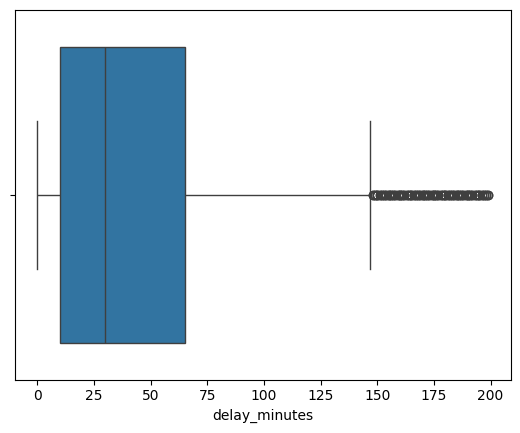

In [31]:
import seaborn as sns
sns.boxplot(x=df['delay_minutes'])

In [32]:
# Remove extreme delays:
df = df[df['delay_minutes'] < 200]

<Axes: xlabel='delay_minutes'>

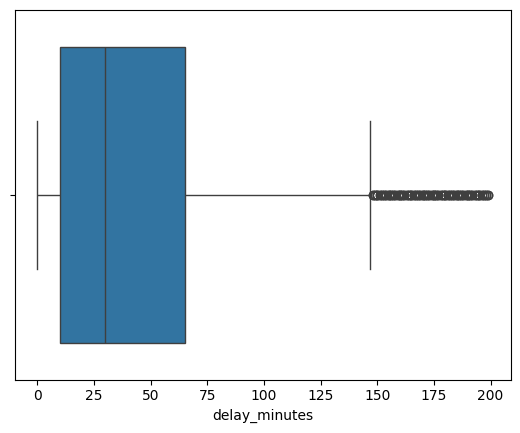

In [33]:
sns.boxplot(x=df['delay_minutes'])

9. > Check Unique Values
   > 
   >  Helps detect:- Wrong categories, Typos

In [34]:
df['weather_conditions'].value_counts()

weather_conditions
clear    748
rainy    746
foggy    718
Name: count, dtype: int64

In [35]:
df['train_type'].value_counts()

train_type
local        752
express      741
superfast    719
Name: count, dtype: int64

In [36]:
df['route_congestion'].value_counts()

route_congestion
medium    748
high      745
low       719
Name: count, dtype: int64

In [37]:
df.head()

,distance_km,weather_conditions,day_of_the_week,time_of_day,train_type,delay_minutes,route_congestion
0,100,clear,monday,morning,express,5,low
1,150,rainy,tuesday,afternoon,superfast,10,medium
2,200,foggy,wednesday,evening,local,15,high
3,50,clear,thursday,night,express,2,low
4,75,rainy,friday,morning,superfast,8,medium


# EDA

EDA (Exploratory Data Analysis) is the process of analyzing and understanding your data using statistics and visualizations to discover patterns, trends, relationships, and problems.

EDA = understanding your data before building a model

1. Why EDA is Important
  * Helps you understand data deeply
  * Finds patterns & relationships
  * Detects outliers & errors
  * Helps in feature selection
  * Improves model accuracy

2. Types of EDA

* Univariate Analysis (Single Column) - Analyze one variable at a time
   * Example:- Age distribution, Salary range
* Bivariate Analysis (Two Columns) - Relationship between two variables
   * Example:- Salary vs Experience, Age vs Purchase
* Multivariate Analysis (Multiple Columns) - Relationship among multiple variables
   * Example: Salary vs Experience vs Education

3. Key Steps in EDA
  * Understand Dataset
  * Check Missing Values
  * Statistical Analysis
  * Univariate Analysis ->
    * Numerical_Data - Histogram, Boxplot.
    * Categorical_Data - Countplot.
  * Bivariate Analysis ->
    * Numerical vs Numerical - Scatter plot.
    * Categorical vs Numerical - Boxplot.
    * Categorical vs Categorical - Crosstab / Heatmap.
  * Detect Outliers

4. Data Cleaning vs EDA
* Data Cleaning - Fix data, Remove errors, Handle missing values.
* EDA - Understand data, Find patterns, Visualization & analysis.

# FULL PROJECT: EDA(Train Delay Analysis)

1. > Problem Understanding (EDA Goal)

Analyze train delays and find factors affecting delay like weather, time, congestion, and train type.

2. > Load Clean Data

In [38]:
df2 = df.copy()

In [39]:
df2.head()

,distance_km,weather_conditions,day_of_the_week,time_of_day,train_type,delay_minutes,route_congestion
0,100,clear,monday,morning,express,5,low
1,150,rainy,tuesday,afternoon,superfast,10,medium
2,200,foggy,wednesday,evening,local,15,high
3,50,clear,thursday,night,express,2,low
4,75,rainy,friday,morning,superfast,8,medium


3. >Basic Exploration EDA

In [40]:
df2.shape

(2212, 7)

In [41]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2212 entries, 0 to 2670
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   distance_km         2212 non-null   int64 
 1   weather_conditions  2212 non-null   object
 2   day_of_the_week     2212 non-null   object
 3   time_of_day         2212 non-null   object
 4   train_type          2212 non-null   object
 5   delay_minutes       2212 non-null   int64 
 6   route_congestion    2212 non-null   object
dtypes: int64(2), object(5)
memory usage: 138.2+ KB


In [42]:
df2.describe()

,distance_km,delay_minutes
count,2212.000000,2212.000000
mean,144.649638,44.398282
std,90.651078,44.885220
min,0.000000,0.000000
25%,70.000000,10.000000
50%,145.000000,30.000000
75%,190.000000,65.000000
max,575.000000,199.000000


4. > Univariate Analysis (Single Column)

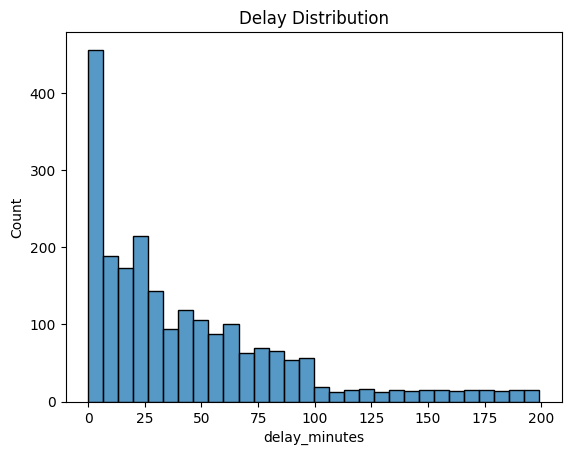

In [43]:
# Delay Distribution - Check if most delays are small or large
sns.histplot(df2['delay_minutes'], bins=30)
plt.title("Delay Distribution")
plt.show()

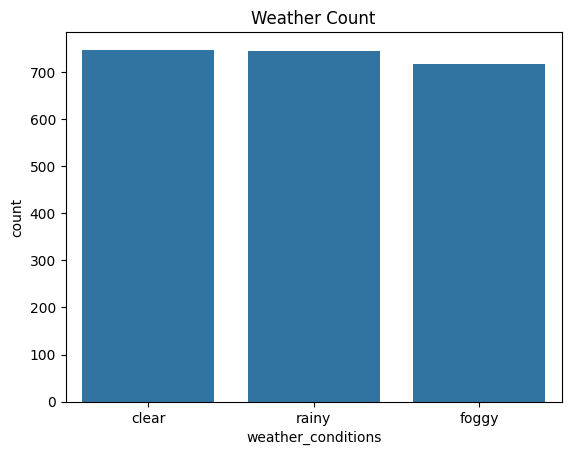

In [44]:
# Weather Distributio
sns.countplot(x='weather_conditions', data=df2)
plt.title("Weather Count")
plt.show()

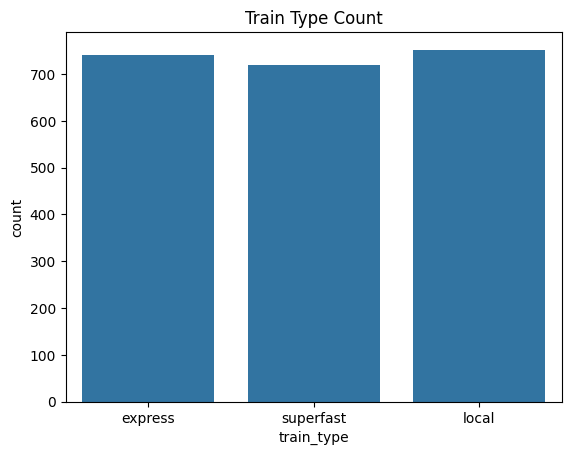

In [45]:
# Train Type Distribution
sns.countplot(x='train_type', data=df2)
plt.title("Train Type Count")
plt.show()

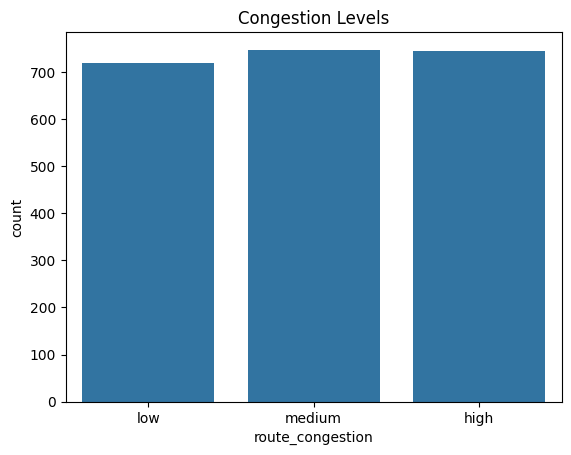

In [46]:
# Route Congestion
sns.countplot(x='route_congestion', data=df2)
plt.title("Congestion Levels")
plt.show()

5. >Bivariate Analysis (Two Variables)

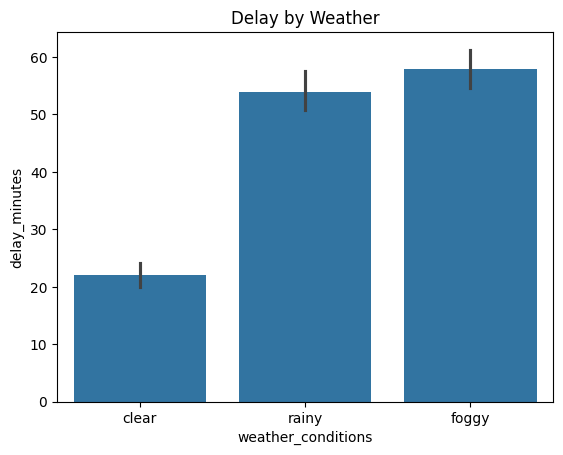

In [47]:
# Delay vs Weather - Rain/Fog may increase delays
sns.barplot(x='weather_conditions', y='delay_minutes', data=df2)
plt.title("Delay by Weather")
plt.show()

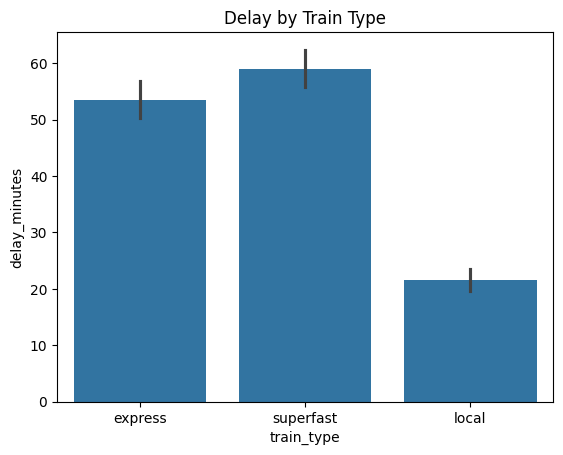

In [48]:
# Delay vs Train Type
sns.barplot(x='train_type', y='delay_minutes', data=df2)
plt.title("Delay by Train Type")
plt.show()

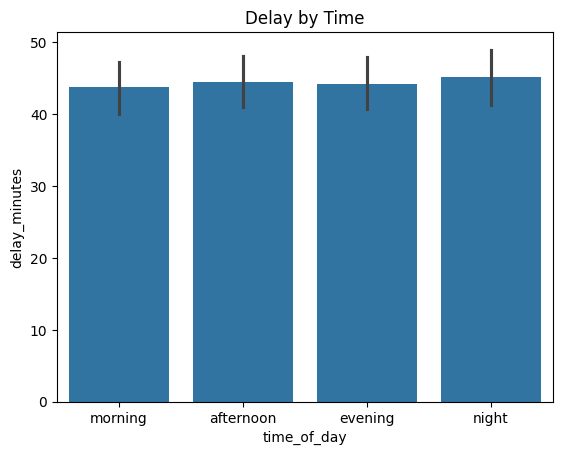

In [49]:
# Delay vs Time of Day
sns.barplot(x='time_of_day', y='delay_minutes', data=df)
plt.title("Delay by Time")
plt.show()

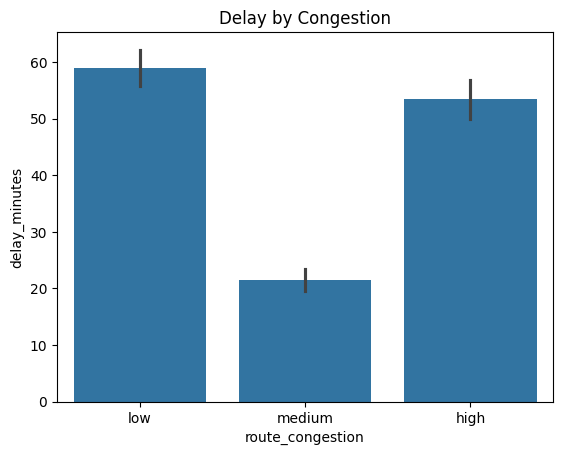

In [50]:
# Delay vs Congestion
sns.barplot(x='route_congestion', y='delay_minutes', data=df)
plt.title("Delay by Congestion")
plt.show()

6. >Multivariate Analysis

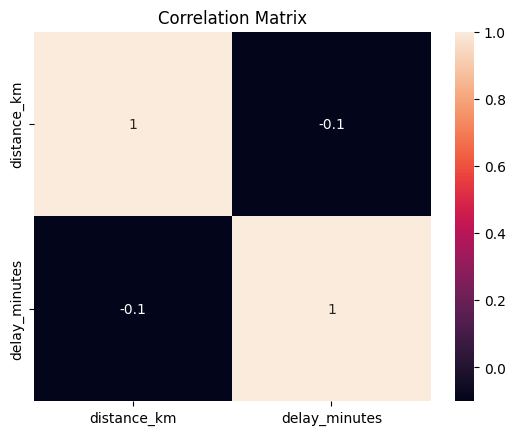

In [51]:
# Heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

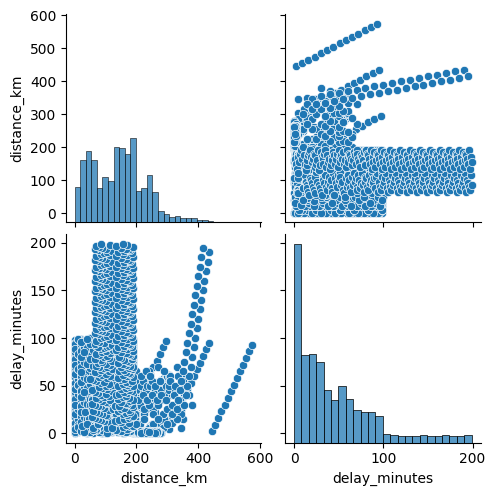

In [52]:
# Pairplot
sns.pairplot(df[['distance_km','delay_minutes']])

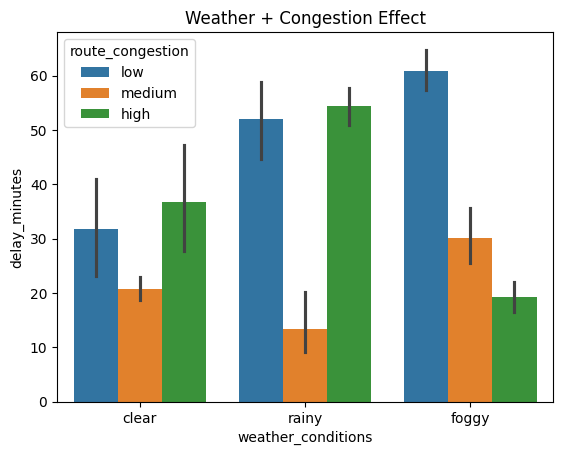

In [53]:
# Combined Analysis
sns.barplot(x='weather_conditions', y='delay_minutes', hue='route_congestion', data=df)
plt.title("Weather + Congestion Effect")
plt.show()

7. > GroupBy Analysis

In [54]:
# Average Delay by Weather
df.groupby('weather_conditions')['delay_minutes'].mean()

weather_conditions
clear    21.955882
foggy    57.856546
rainy    53.947721
Name: delay_minutes, dtype: float64

In [55]:
# Delay by Train Type
df.groupby('train_type')['delay_minutes'].mean()

train_type
express      53.479082
local        21.527926
superfast    58.959666
Name: delay_minutes, dtype: float64

8. > Outlier Analysis

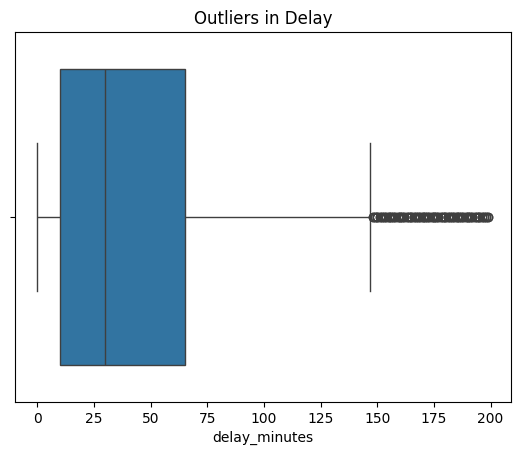

In [56]:
sns.boxplot(x='delay_minutes', data=df)
plt.title("Outliers in Delay")
plt.show()

9. > Feature Relationships

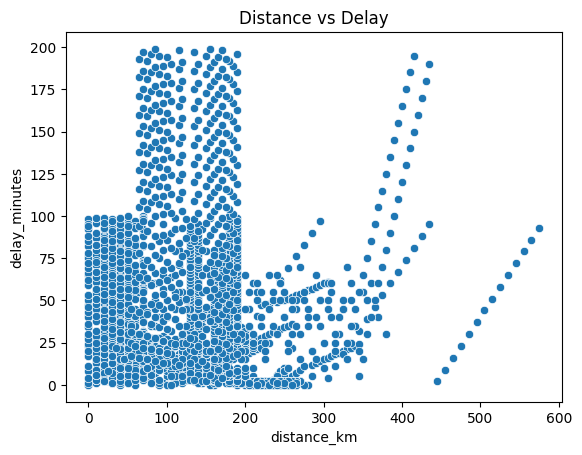

In [57]:
# Distance vs Delay
sns.scatterplot(x='distance_km', y='delay_minutes', data=df)
plt.title("Distance vs Delay")
plt.show()

* Key Insights (VERY IMPORTANT)

Write insights like a Data Analyst:

✔ Rainy and foggy weather increases delays

✔ High congestion leads to higher delays

✔ Superfast trains may have less delay

✔ Evening and morning (peak time) have more delays

✔ Distance slightly affects delay

# Feature Engineering & Feature Selection

1. > FEATURE ENGINEERING

Feature Engineering is the process of creating, transforming, and improving features (columns) from raw data to make it more useful.

Why Feature Engineering is Important

✔ Improves accuracy

✔ Helps models understand data

✔ Converts raw data into useful format

✔ Extracts hidden patterns

1. TYPES OF FEATURE ENGINEERING
   1. Creating New Features - Create new columns from existing data.
      * BMI = weight / height²
      * price_per_sqft = price / area
   2. Transformation of Feature - Change feature values into better format.
   3. Handling Date & Time Features
      * df['year'] = df['date'].dt.year
      * df['month'] = df['date'].dt.month
      * df['day'] = df['date'].dt.day
      * df['weekday'] = df['date'].dt.weekday
      * Day, Month, Year, Weekday, Hour find from existing date feature
   4. Text Feature Engineering - Extract information from text. and store information in new feature created.
   5. Removing Irrelevant Features -  Drop useless columns.
   6. Binning (Discretization)
      * Convert continuous columns → categories columns, distance → short, medium, long
      * eg:- df['age_group'] = pd.cut(df['age'], bins=[0,18,40,60,100], labels=['child','young','adult','old'])

   >main types of FEATURE ENGINEERING and ML steps
   
   7. Encoding Categorical Data - Convert text → numbers, we have 2 types label encoding and one-hot encoding
      * Label Encoding - Assign numbers to categories. they change 2 values in number eg.(male, female)(0, 1).
        * eg :- df2['sex'] = df2['sex'].map({'male':0, 'female':1})
      * One-Hot Encoding - Create separate columns. they change more than 2 values in number by separate columns.
        * create columns into diffrent columns on the basses of number of categories in columns.
        * eg:- (weather_column =(create diffrent columns) weather_clear, weather_rainy, weather_foggy) and make it astype(int)
        * df = pd.get_dummies(df, columns=['weather']) # create by this
   8. Feature Scaling - Feature Scaling is the process of transforming numerical features so that they are on a similar scale (range or distribution).0-1
      * Types of Feature Scaling
        * Min-Max Scaling (0 to 1)
        * Standardization (mean = 0, std = 1)(mostly use)
          * Converts data into normal distribution (mean = 0, std = 1)
          * from sklearn.preprocessing import StandardScaler
          * scaler = StandardScaler()
          * df_scaled = scaler.fit_transform(df)

2. > FEATURE SELECTION

Feature Selection is the process of selecting important features and removing unnecessary ones.

Why Feature Selection is Important

✔ Reduces overfitting

✔ Improves speed

✔ Improves accuracy

✔ Removes noise

1. TYPES OF FEATURE SELECTION
   1. Filter Methods - Filter Methods select features using statistical techniques.
      * Correlation-Based Feature Selection - Measures linear relationship between feature and target
         * +1  → strong positive, 0  → no relation, -1  → strong negative
         * code - corr = df.corr(), sns.heatmap(corr, annot=True), plt.show()
      * If two features are highly correlated with each other :- Keep only one.
      * 
   2. Wrapper Methods - Try different feature combinations.
   3. Embedded Methods - 👉 Feature selection inside model.
   4. Unique Value Check - 👉 Remove columns with:
   5. Feature Importance (Concept) - 👉 Identify important features.

# FULL PROJECT: FEATURE ENGINEERING and Feature Selection

# PART 1: FEATURE ENGINEERING

In [58]:
# our data frame
df2.head()

,distance_km,weather_conditions,day_of_the_week,time_of_day,train_type,delay_minutes,route_congestion
0,100,clear,monday,morning,express,5,low
1,150,rainy,tuesday,afternoon,superfast,10,medium
2,200,foggy,wednesday,evening,local,15,high
3,50,clear,thursday,night,express,2,low
4,75,rainy,friday,morning,superfast,8,medium


1. > Create New Features

In [59]:
# Weekend Feature
df2['is_weekend'] = df2['day_of_the_week'].isin(['saturday','sunday']).astype(int)

In [60]:
# Peak Time Feature
df2['is_peak'] = df2['time_of_day'].isin(['morning','evening']).astype(int)

In [61]:
# High Delay Flag
df2['high_delay'] = (df2['delay_minutes'] > 15).astype(int)

In [62]:
df2.head()

,distance_km,weather_conditions,day_of_the_week,time_of_day,train_type,delay_minutes,route_congestion,is_weekend,is_peak,high_delay
0,100,clear,monday,morning,express,5,low,0,1,0
1,150,rainy,tuesday,afternoon,superfast,10,medium,0,0,0
2,200,foggy,wednesday,evening,local,15,high,0,1,0
3,50,clear,thursday,night,express,2,low,0,0,0
4,75,rainy,friday,morning,superfast,8,medium,0,1,0


2. > Interaction Features

In [63]:
df2['weather_congestion'] = df2['weather_conditions'] + "_" + df2['route_congestion']

In [64]:
df2.head()

,distance_km,weather_conditions,day_of_the_week,time_of_day,train_type,delay_minutes,route_congestion,is_weekend,is_peak,high_delay,weather_congestion
0,100,clear,monday,morning,express,5,low,0,1,0,clear_low
1,150,rainy,tuesday,afternoon,superfast,10,medium,0,0,0,rainy_medium
2,200,foggy,wednesday,evening,local,15,high,0,1,0,foggy_high
3,50,clear,thursday,night,express,2,low,0,0,0,clear_low
4,75,rainy,friday,morning,superfast,8,medium,0,1,0,rainy_medium


3. > Binning

In [65]:
# Distance Category
df2['distance_category'] = pd.cut(
    df['distance_km'],
    bins=[0,50,150,300],
    labels=['short','medium','long']
)

In [66]:
df2.head()

,distance_km,weather_conditions,day_of_the_week,time_of_day,train_type,delay_minutes,route_congestion,is_weekend,is_peak,high_delay,weather_congestion,distance_category
0,100,clear,monday,morning,express,5,low,0,1,0,clear_low,medium
1,150,rainy,tuesday,afternoon,superfast,10,medium,0,0,0,rainy_medium,medium
2,200,foggy,wednesday,evening,local,15,high,0,1,0,foggy_high,long
3,50,clear,thursday,night,express,2,low,0,0,0,clear_low,short
4,75,rainy,friday,morning,superfast,8,medium,0,1,0,rainy_medium,medium


4. >Encoding (Convert text → number)

In [67]:
#Label Encoding (Manual)
df2['train_type'] = df2['train_type'].map({
    'local':0,
    'express':1,
    'superfast':2
})

In [ ]:
#Label Encoding (sklearn ML lib)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['train_type'] = le.fit_transform(df['train_type'])

In [68]:
df2.head()

,distance_km,weather_conditions,day_of_the_week,time_of_day,train_type,delay_minutes,route_congestion,is_weekend,is_peak,high_delay,weather_congestion,distance_category
0,100,clear,monday,morning,1,5,low,0,1,0,clear_low,medium
1,150,rainy,tuesday,afternoon,2,10,medium,0,0,0,rainy_medium,medium
2,200,foggy,wednesday,evening,0,15,high,0,1,0,foggy_high,long
3,50,clear,thursday,night,1,2,low,0,0,0,clear_low,short
4,75,rainy,friday,morning,2,8,medium,0,1,0,rainy_medium,medium


In [69]:
# One-Hot Encoding
df2 = pd.get_dummies(df2, columns=['weather_conditions','route_congestion'])

In [70]:
df2.head()

,distance_km,day_of_the_week,time_of_day,train_type,delay_minutes,is_weekend,is_peak,high_delay,weather_congestion,distance_category,weather_conditions_clear,weather_conditions_foggy,weather_conditions_rainy,route_congestion_high,route_congestion_low,route_congestion_medium
0,100,monday,morning,1,5,0,1,0,clear_low,medium,True,False,False,False,True,False
1,150,tuesday,afternoon,2,10,0,0,0,rainy_medium,medium,False,False,True,False,False,True
2,200,wednesday,evening,0,15,0,1,0,foggy_high,long,False,True,False,True,False,False
3,50,thursday,night,1,2,0,0,0,clear_low,short,True,False,False,False,True,False
4,75,friday,morning,2,8,0,1,0,rainy_medium,medium,False,False,True,False,False,True


# PART 2: FEATURE SELECTION

In [71]:
# Remove Unnecessary Columns
df2.drop(columns=['day_of_the_week','time_of_day'], inplace=True)
# Because you already created:- is_weekend, is_peak

In [72]:
 # If two features are highly similar → remove one
df2.corr(numeric_only=True)

,distance_km,train_type,delay_minutes,is_weekend,is_peak,high_delay,weather_conditions_clear,weather_conditions_foggy,weather_conditions_rainy,route_congestion_high,route_congestion_low,route_congestion_medium
distance_km,1.000000,-0.204529,-0.100779,0.002816,-0.006595,-0.178412,0.237577,-0.132512,-0.106497,-0.096878,-0.127774,0.223290
train_type,-0.204529,1.000000,0.341860,0.010264,0.007274,0.444489,-0.761631,0.712541,0.056446,0.007173,0.808186,-0.807340
delay_minutes,-0.100779,0.341860,1.000000,0.006903,-0.009532,0.600108,-0.357474,0.207908,0.151801,0.142353,0.225568,-0.365545
is_weekend,0.002816,0.010264,0.006903,1.000000,-0.000265,0.006907,-0.001454,0.003868,-0.002376,-0.003899,0.007546,-0.003575
is_peak,-0.006595,0.007274,-0.009532,-0.000265,1.000000,-0.021711,0.010793,0.005217,-0.015967,-0.007360,0.004246,0.003149
high_delay,-0.178412,0.444489,0.600108,0.006907,-0.021711,1.000000,-0.455416,0.315868,0.142886,0.138179,0.312285,-0.447231
weather_conditions_clear,0.237577,-0.761631,-0.357474,-0.001454,0.010793,-0.455416,1.000000,-0.495527,-0.509897,-0.442657,-0.420551,0.858603
weather_conditions_foggy,-0.132512,0.712541,0.207908,0.003868,0.005217,0.315868,-0.495527,1.000000,-0.494526,-0.483812,0.856736,-0.364908
weather_conditions_rainy,-0.106497,0.056446,0.151801,-0.002376,-0.015967,0.142886,-0.509897,-0.494526,1.000000,0.922104,-0.427666,-0.497770
route_congestion_high,-0.096878,0.007173,0.142353,-0.003899,-0.007360,0.138179,-0.442657,-0.483812,0.922104,1.000000,-0.494536,-0.509382


In [73]:
# Check Unique Values
df2.nunique()

distance_km                 100
train_type                    3
delay_minutes               200
is_weekend                    2
is_peak                       2
high_delay                    2
weather_congestion            9
distance_category             3
weather_conditions_clear      2
weather_conditions_foggy      2
weather_conditions_rainy      2
route_congestion_high         2
route_congestion_low          2
route_congestion_medium       2
dtype: int64